**Bagian 1**: Shot 10.000 kali

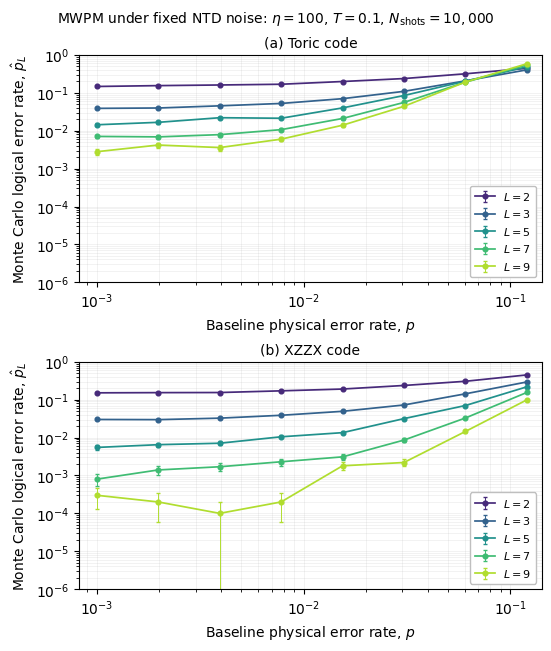

Saved figure1_mc_mwpm.pdf and figure1_mc_mwpm.png


In [15]:
#!/usr/bin/env python3
"""Figure 1: logical error rate versus baseline physical error rate."""

import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pymatching

from __future__ import annotations
import argparse
from dataclasses import dataclass
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

try:
    import pymatching
except ImportError:
    pymatching = None

@dataclass(frozen=True)
class ToricLattice:
    h_star: np.ndarray
    h_plaq: np.ndarray
    xbar: np.ndarray
    zbar: np.ndarray
    horizontal: np.ndarray

def build_toric_lattice(L: int) -> ToricLattice:
    if L < 2: raise ValueError("L must be at least 2")
    n = 2 * L * L
    H = lambda i,j: (i % L) * L + (j % L)
    V = lambda i,j: L * L + (i % L) * L + (j % L)
    h_star, h_plaq = np.zeros((L*L,n),dtype=np.uint8), np.zeros((L*L,n),dtype=np.uint8)

    for i in range(L):
        for j in range(L):
            k = i*L+j
            for e in (H(i,j),H(i-1,j),V(i,j),V(i,j-1)): h_star[k,e] ^= 1
            for e in (H(i,j),H(i,j+1),V(i,j),V(i+1,j)): h_plaq[k,e] ^= 1

    xbar, zbar = np.zeros((2,n),dtype=np.uint8), np.zeros((2,n),dtype=np.uint8)
    for i in range(L): xbar[0,V(i,0)] = 1; zbar[0,H(i,0)] = 1
    for j in range(L): xbar[1,H(0,j)] = 1; zbar[1,V(0,j)] = 1

    horizontal = np.zeros(n,dtype=bool); horizontal[:L*L] = True
    return ToricLattice(h_star,h_plaq,xbar,zbar,horizontal)

def effective_rates(p: float, eta: float, temperature: float, t0: float = 1.2, p_inf: float = 0.5) -> tuple[float,float]:
    p_eff = p + (p_inf-p)*(1-np.exp(-temperature/t0))
    p_a = p_eff/(1+eta); p_b = p_eff*(2*eta+1)/(2*(1+eta))
    if not (0 < p_a < 0.5 and 0 < p_b < 0.5): raise ValueError(f"Invalid effective rates: p_a={p_a:.4g}, p_b={p_b:.4g}")
    return p_a,p_b

def sector_rates(code: str, lattice: ToricLattice, p_a: float, p_b: float) -> tuple[np.ndarray,np.ndarray]:
    n = lattice.horizontal.size
    if code == "toric": return np.full(n,p_a),np.full(n,p_b)
    if code == "xzzx": return np.where(lattice.horizontal,p_a,p_b),np.where(lattice.horizontal,p_b,p_a)
    raise ValueError(f"Unknown code: {code}")

def make_matching(check_matrix: np.ndarray, error_rates: np.ndarray):
    if pymatching is None: raise ImportError("PyMatching is not installed.")
    return pymatching.Matching(check_matrix,weights=np.log((1-error_rates)/error_rates))

def decode_failures(matching, errors: np.ndarray, check_matrix: np.ndarray, logical_test: np.ndarray) -> np.ndarray:
    syndromes = (errors @ check_matrix.T) & 1
    recovery = np.asarray(matching.decode_batch(syndromes),dtype=np.uint8)
    residual = errors ^ recovery
    return np.any((residual @ logical_test.T) & 1,axis=1)

def simulate_point(code: str, lattice: ToricLattice, p: float, eta: float, temperature: float, shots: int, rng: np.random.Generator) -> tuple[float,float]:
    p_a,p_b = effective_rates(p,eta,temperature)
    x_rates,z_rates = sector_rates(code,lattice,p_a,p_b)
    x_matching,z_matching = make_matching(lattice.h_plaq,x_rates),make_matching(lattice.h_star,z_rates)
    x_errors = (rng.random((shots,x_rates.size)) < x_rates).astype(np.uint8)
    z_errors = (rng.random((shots,z_rates.size)) < z_rates).astype(np.uint8)
    x_fail = decode_failures(x_matching,x_errors,lattice.h_plaq,lattice.zbar)
    z_fail = decode_failures(z_matching,z_errors,lattice.h_star,lattice.xbar)
    p_logical = np.count_nonzero(x_fail | z_fail)/shots
    return p_logical,np.sqrt(p_logical*(1-p_logical)/shots)

def run_figure(L_values: list[int], p_values: np.ndarray, eta: float, temperature: float, shots: int, seed: int, output: Path) -> None:
    lattices = {L: build_toric_lattice(L) for L in L_values}
    colors = plt.get_cmap("viridis")(np.linspace(0.12,0.88,len(L_values)))
    rng = np.random.default_rng(seed)

    fig,axes = plt.subplots(2,1,figsize=(5.4,6.4),sharex=True,constrained_layout=True)

    for ax,code,title in zip(axes,("toric","xzzx"),("(a) Toric code","(b) XZZX code")):
        for L,color in zip(L_values,colors):
            estimates,errors = [],[]
            for p in p_values:
                estimate,uncertainty = simulate_point(code,lattices[L],float(p),eta,temperature,shots,rng)
                estimates.append(estimate); errors.append(uncertainty)

            estimates,errors = np.asarray(estimates),np.asarray(errors)

            ax.errorbar(
                p_values,np.maximum(estimates,0.5/shots),yerr=errors,
                marker="o",markersize=3.4,linewidth=1.25,elinewidth=0.7,
                capsize=1.6,color=color,label=fr"$L={L}$"
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(p_values.min()*0.82,p_values.max()*1.18)
        ax.set_ylim(1e-6,1.0)
        ax.set_xticks([1e-3,1e-2,1e-1])
        ax.set_xticklabels([r"$10^{-3}$",r"$10^{-2}$",r"$10^{-1}$"])
        ax.grid(which="both",alpha=0.22,linewidth=0.5)
        ax.set_title(title,fontsize=10)
        ax.set_xlabel(r"Baseline physical error rate, $p$")
        ax.set_ylabel(r"Monte Carlo logical error rate, $\hat{p}_L$")
        ax.legend(
            loc="lower right",frameon=True,facecolor="white",
            framealpha=1.0,edgecolor="0.75",fontsize=8,handlelength=1.8
        )

    axes[0].tick_params(axis="x",which="both",labelbottom=True)

    fig.suptitle(
        fr"MWPM under fixed NTD noise: $\eta={eta:g}$, $T={temperature:g}$, "
        fr"$N_{{\rm shots}}={shots:,}$",fontsize=10
    )

    output.parent.mkdir(parents=True,exist_ok=True)
    fig.savefig(output.with_suffix(".pdf"),bbox_inches="tight")
    fig.savefig(output.with_suffix(".png"),dpi=450,bbox_inches="tight")
    plt.show()
    plt.close(fig)

def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--L",type=int,nargs="+",default=[2,3,5,7,9])
    parser.add_argument("--eta",type=float,default=100.0)
    parser.add_argument("--temperature","--T",type=float,default=0.1)
    parser.add_argument("--shots",type=int,default=10_000)
    parser.add_argument("--num-points",type=int,default=12)
    parser.add_argument("--p-min",type=float,default=1e-3)
    parser.add_argument("--p-max",type=float,default=1.2e-1)
    parser.add_argument("--seed",type=int,default=20260916)
    parser.add_argument("--output",type=Path,default=Path("figure1_mc_mwpm"))
    args,_ = parser.parse_known_args()

    if args.shots < 1: raise ValueError("--shots must be positive")
    if not (0 < args.p_min < args.p_max < 0.5): raise ValueError("Require 0 < p-min < p-max < 0.5")

    p_values = np.geomspace(args.p_min,args.p_max,args.num_points)
    for p in p_values: effective_rates(float(p),args.eta,args.temperature)

    run_figure(args.L,p_values,args.eta,args.temperature,args.shots,args.seed,args.output)
    print(f"Saved {args.output.with_suffix('.pdf')} and {args.output.with_suffix('.png')}")

if __name__ == "__main__":
    sys.argv = [sys.argv[0],"--shots","10000","--num-points","8"]
    main()

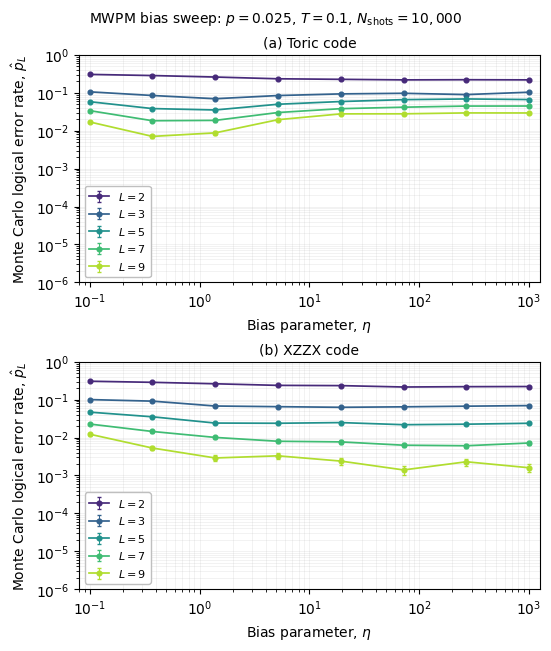

Saved figure2_mc_mwpm.pdf and figure2_mc_mwpm.png


In [18]:
#!/usr/bin/env python3
"""Figure 2: logical error rate versus bias parameter eta with MWPM."""

from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    from figure1_mc_mwpm import build_toric_lattice, effective_rates, simulate_point
except ModuleNotFoundError:
    from __main__ import build_toric_lattice, effective_rates, simulate_point


def run_figure(L_values: list[int], eta_values: np.ndarray, p: float, temperature: float, shots: int, seed: int, output: Path, show: bool) -> None:
    lattices = {L: build_toric_lattice(L) for L in L_values}
    colors = plt.get_cmap("viridis")(np.linspace(0.12, 0.88, len(L_values)))
    rng = np.random.default_rng(seed)

    fig, axes = plt.subplots(2, 1, figsize=(5.4, 6.4), sharex=True, constrained_layout=True)

    for ax, code, title in zip(axes, ("toric", "xzzx"), ("(a) Toric code", "(b) XZZX code")):
        for L, color in zip(L_values, colors):
            estimates, uncertainties = [], []
            for eta in eta_values:
                estimate, uncertainty = simulate_point(code, lattices[L], p, float(eta), temperature, shots, rng)
                estimates.append(estimate); uncertainties.append(uncertainty)

            estimates, uncertainties = np.asarray(estimates), np.asarray(uncertainties)
            ax.errorbar(eta_values, np.maximum(estimates, 0.5 / shots), yerr=uncertainties, marker="o", markersize=3.4, linewidth=1.25, elinewidth=0.7, capsize=1.6, color=color, label=fr"$L={L}$")

        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(eta_values.min() * 0.80, eta_values.max() * 1.25)
        ax.set_ylim(1e-6, 1.0)
        ax.grid(which="both", alpha=0.22, linewidth=0.5)
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(r"Monte Carlo logical error rate, $\hat{p}_L$")
        ax.legend(loc="lower left", frameon=True, facecolor="white", framealpha=1.0, edgecolor="0.75", fontsize=8, handlelength=1.8)

    axes[0].set_xticks([1e-1, 1e0, 1e1, 1e2, 1e3])
    axes[0].set_xticklabels([r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"])
    axes[0].tick_params(axis="x", which="both", labelbottom=True)
    axes[0].set_xlabel(r"Bias parameter, $\eta$")
    axes[1].set_xlabel(r"Bias parameter, $\eta$")

    fig.suptitle(fr"MWPM bias sweep: $p={p:g}$, $T={temperature:g}$, $N_{{\rm shots}}={shots:,}$", fontsize=10)

    output.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(output.with_suffix(".png"), dpi=450, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--L", type=int, nargs="+", default=[2, 3, 5, 7, 9])
    parser.add_argument("--p", type=float, default=0.02)
    parser.add_argument("--temperature", "--T", type=float, default=0.10)
    parser.add_argument("--eta-min", type=float, default=0.1)
    parser.add_argument("--eta-max", type=float, default=1000.0)
    parser.add_argument("--num-points", type=int, default=13)
    parser.add_argument("--shots", type=int, default=100_000)
    parser.add_argument("--seed", type=int, default=20260917)
    parser.add_argument("--output", type=Path, default=Path("figure2_mc_mwpm"))
    parser.add_argument("--show", action="store_true")
    args, _ = parser.parse_known_args()

    if args.shots < 1: raise ValueError("--shots must be positive")
    if not (0.0 < args.eta_min < args.eta_max): raise ValueError("Require 0 < eta-min < eta-max")

    eta_values = np.geomspace(args.eta_min, args.eta_max, args.num_points)
    for eta in eta_values: effective_rates(args.p, float(eta), args.temperature)

    run_figure(args.L, eta_values, args.p, args.temperature, args.shots, args.seed, args.output, args.show)
    print(f"Saved {args.output.with_suffix('.pdf')} and {args.output.with_suffix('.png')}")


if __name__ == "__main__":
    import sys
    sys.argv = [sys.argv[0], "--shots", "10000", "--num-points", "8", "--show"]
    main()

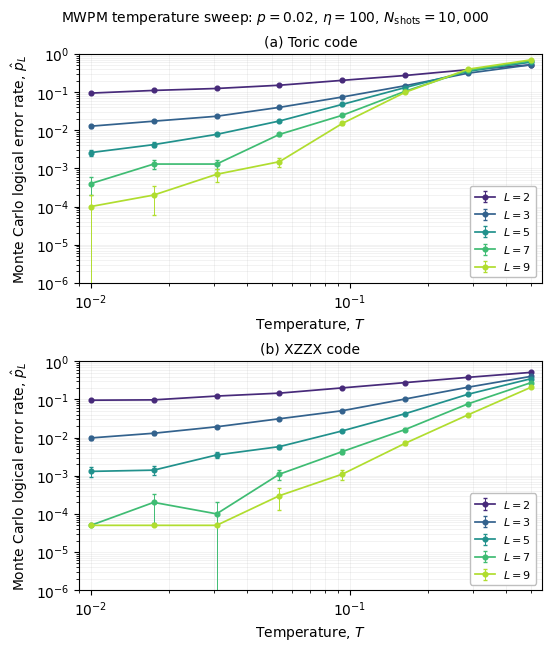

Saved figure3_mc_mwpm.pdf and figure3_mc_mwpm.png


In [23]:
#!/usr/bin/env python3
"""Figure 3: logical error rate versus temperature T with MWPM."""

from __future__ import annotations
import argparse
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

try:
    from figure1_mc_mwpm import build_toric_lattice, effective_rates, simulate_point
except ModuleNotFoundError:
    try:
        from __main__ import build_toric_lattice, effective_rates, simulate_point
    except ImportError as error:
        raise ImportError(
            "Run the Figure 1 definition cell first, or save Figure 1 as "
            "figure1_mc_mwpm.py in the same folder as this script."
        ) from error


def run_figure(L_values: list[int], temperatures: np.ndarray, p: float,
               eta: float, shots: int, seed: int, output: Path) -> None:
    """Run and save the Figure 3 temperature sweep."""
    lattices = {L: build_toric_lattice(L) for L in L_values}
    colors = plt.get_cmap("viridis")(np.linspace(0.12, 0.88, len(L_values)))
    rng = np.random.default_rng(seed)

    fig, axes = plt.subplots(2, 1, figsize=(5.4, 6.4), sharex=True, constrained_layout=True)

    for ax, code, title in zip(axes, ("toric", "xzzx"), ("(a) Toric code", "(b) XZZX code")):
        for L, color in zip(L_values, colors):
            estimates, uncertainties = [], []

            for temperature in temperatures:
                estimate, uncertainty = simulate_point(
                    code, lattices[L], p, eta, float(temperature), shots, rng
                )
                estimates.append(estimate)
                uncertainties.append(uncertainty)

            estimates, uncertainties = np.asarray(estimates), np.asarray(uncertainties)
            ax.errorbar(
                temperatures, np.maximum(estimates, 0.5 / shots), yerr=uncertainties,
                marker="o", markersize=3.4, linewidth=1.25, elinewidth=0.7,
                capsize=1.6, color=color, label=fr"$L={L}$"
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(temperatures.min() * 0.9, temperatures.max() * 1.1)
        ax.set_ylim(1e-6, 1.0)
        ax.grid(which="both", alpha=0.22, linewidth=0.5)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel(r"Temperature, $T$")
        ax.set_ylabel(r"Monte Carlo logical error rate, $\hat{p}_L$")
        ax.legend(
            loc="lower right", frameon=True, facecolor="white",
            framealpha=1.0, edgecolor="0.75", fontsize=8, handlelength=1.8
        )

    axes[0].tick_params(axis="x", which="both", labelbottom=True)

    fig.suptitle(
        fr"MWPM temperature sweep: $p={p:g}$, $\eta={eta:g}$, "
        fr"$N_{{\rm shots}}={shots:,}$", fontsize=10
    )

    output.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(output.with_suffix(".png"), dpi=450, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--L", type=int, nargs="+", default=[2, 3, 5, 7, 9])
    parser.add_argument("--p", type=float, default=0.02)
    parser.add_argument("--eta", type=float, default=100.0)
    parser.add_argument("--T-min", type=float, default=0.01)
    parser.add_argument("--T-max", type=float, default=0.5)
    parser.add_argument("--num-points", type=int, default=11)
    parser.add_argument("--shots", type=int, default=100_000)
    parser.add_argument("--seed", type=int, default=20260918)
    parser.add_argument("--output", type=Path, default=Path("figure3_mc_mwpm"))
    args, _ = parser.parse_known_args()

    if args.shots < 1:
        raise ValueError("--shots must be positive")
    if not (0.0 < args.T_min < args.T_max):
        raise ValueError("Require 0 < T-min < T-max for a logarithmic temperature axis")

    temperatures = np.geomspace(args.T_min, args.T_max, args.num_points)

    for temperature in temperatures:
        effective_rates(args.p, args.eta, float(temperature))

    run_figure(
        args.L, temperatures, args.p, args.eta,
        args.shots, args.seed, args.output
    )

    print(f"Saved {args.output.with_suffix('.pdf')} and {args.output.with_suffix('.png')}")


if __name__ == "__main__":
    import sys
    sys.argv = [sys.argv[0], "--shots", "10000", "--num-points", "8"]
    main()

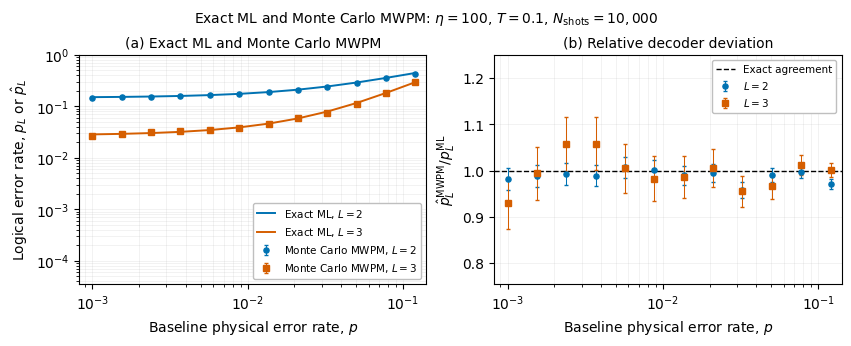

Saved figure4_exact_ml_vs_mwpm.pdf and figure4_exact_ml_vs_mwpm.png


In [ ]:
#!/usr/bin/env python3
"""Figure 4: exact maximum-likelihood decoding versus Monte Carlo MWPM.

The figure validates the XZZX MWPM implementation for L=2 and L=3.  Exact
maximum-likelihood (ML) decoding enumerates all binary error configurations
within each independently decoded sector.  MWPM results are sampled using the
same p -> p_eff -> p_NTD^(a,b) noise model and include binomial 1-sigma bars.
"""

from __future__ import annotations

import argparse
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    from figure1_mc_mwpm import build_toric_lattice, effective_rates, sector_rates, simulate_point
except ModuleNotFoundError:
    try:
        from __main__ import build_toric_lattice, effective_rates, sector_rates, simulate_point
    except ImportError as error:
        raise ImportError(
            "Run the Figure 1 definition cell first, or save Figure 1 as "
            "figure1_mc_mwpm.py in the same folder as this script."
        ) from error


@lru_cache(maxsize=None)
def all_binary_errors(n_qubits: int) -> np.ndarray:
    """Return the 2^n binary configurations, feasible here only for L=2,3."""
    indices = np.arange(1 << n_qubits, dtype=np.uint32)
    return ((indices[:, None] >> np.arange(n_qubits)) & 1).astype(np.uint8)


def exact_sector_failure(check_matrix: np.ndarray, logical_test: np.ndarray,
                         rates: np.ndarray) -> float:
    """Exact ML logical failure for one binary sector.

    For each syndrome, configurations are grouped by their two-bit logical
    homology class.  ML selects the most probable class; all remaining
    probability is logical failure.
    """
    errors = all_binary_errors(rates.size)
    syndrome = (errors @ check_matrix.T) & 1
    syndrome_id = syndrome @ (1 << np.arange(check_matrix.shape[0]))
    logical_class = ((errors @ logical_test.T) & 1) @ np.array([1, 2])

    probabilities = np.prod(np.where(errors, rates, 1.0 - rates), axis=1)
    grouped_id = 4 * syndrome_id + logical_class
    class_probability = np.bincount(
        grouped_id, weights=probabilities, minlength=(1 << check_matrix.shape[0]) * 4
    ).reshape(-1, 4)
    return 1.0 - np.max(class_probability, axis=1).sum()


def exact_xzzx_failure(L: int, p: float, eta: float, temperature: float) -> float:
    """Combine exact ML failures of the independent XZZX sectors."""
    lattice = build_toric_lattice(L)
    p_a, p_b = effective_rates(p, eta, temperature)
    x_rates, z_rates = sector_rates("xzzx", lattice, p_a, p_b)
    p_x = exact_sector_failure(lattice.h_plaq, lattice.zbar, x_rates)
    p_z = exact_sector_failure(lattice.h_star, lattice.xbar, z_rates)
    return 1.0 - (1.0 - p_x) * (1.0 - p_z)


def run_figure(p_values: np.ndarray, eta: float, temperature: float, shots: int,
               seed: int, output: Path) -> None:
    """Plot decoder comparison and the MWPM-to-ML ratio for L=2 and L=3."""
    rng = np.random.default_rng(seed)
    fig, (ax, ax_ratio) = plt.subplots(1, 2, figsize=(8.4, 3.35), sharex=True,
                                       constrained_layout=True)
    styles = {2: ("#0072B2", "o"), 3: ("#D55E00", "s")}
    ratio_extrema: list[float] = []

    for L in (2, 3):
        color, marker = styles[L]
        lattice = build_toric_lattice(L)
        exact_values, mwpm_values, uncertainties = [], [], []
        for p in p_values:
            exact_values.append(exact_xzzx_failure(L, float(p), eta, temperature))
            estimate, uncertainty = simulate_point(
                "xzzx", lattice, float(p), eta, temperature, shots, rng
            )
            mwpm_values.append(estimate)
            uncertainties.append(uncertainty)

        exact_values = np.asarray(exact_values)
        mwpm_values = np.asarray(mwpm_values)
        uncertainties = np.asarray(uncertainties)
        ax.plot(p_values, np.maximum(exact_values, 0.5 / shots), color=color,
                linewidth=1.4, label=fr"Exact ML, $L={L}$")
        ax.errorbar(p_values, np.maximum(mwpm_values, 0.5 / shots),
                    yerr=uncertainties, linestyle="none", marker=marker, markersize=3.7,
                    color=color, elinewidth=0.75, capsize=1.7,
                    label=fr"Monte Carlo MWPM, $L={L}$")

        # A relative difference is meaningful only when the exact logical
        # failure rate predicts at least ten failures in the MC sample.
        reliable = exact_values * shots >= 10.0
        ratio = mwpm_values[reliable] / exact_values[reliable]
        ratio_error = uncertainties[reliable] / exact_values[reliable]
        ax_ratio.errorbar(
            p_values[reliable], ratio, yerr=ratio_error, linestyle="none",
            marker=marker, markersize=3.7, color=color, elinewidth=0.75,
            capsize=1.7, label=fr"$L={L}$",
        )
        if ratio.size:
            ratio_extrema.extend((ratio - ratio_error).tolist())
            ratio_extrema.extend((ratio + ratio_error).tolist())

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(p_values.min() * 0.82, p_values.max() * 1.18)
    ax.set_ylim(0.35 / shots, 1.0)
    ax.grid(which="both", alpha=0.22, linewidth=0.5)
    ax.set_xlabel(r"Baseline physical error rate, $p$")
    ax.set_ylabel(r"Logical error rate, $p_L$ or $\hat{p}_L$")
    ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=1.0, edgecolor="0.75", fontsize=7.5, handlelength=1.8)

    ax.set_title(r"(a) Exact ML and Monte Carlo MWPM", fontsize=10)
    ax_ratio.axhline(1.0, color="black", linestyle="--", linewidth=1.0, label="Exact agreement")
    ax_ratio.set_xscale("log")
    ax_ratio.set_xlim(p_values.min() * 0.82, p_values.max() * 1.18)
    ax_ratio.grid(which="both", alpha=0.22, linewidth=0.5)
    ax_ratio.set_xlabel(r"Baseline physical error rate, $p$")
    ax_ratio.set_ylabel(r"$\hat{p}_L^{\mathrm{MWPM}} / p_L^{\mathrm{ML}}$")
    ax_ratio.set_title(r"(b) Relative decoder deviation", fontsize=10)
    if ratio_extrema:
        lower = max(0.0, min(ratio_extrema) - 0.12)
        upper = max(1.25, max(ratio_extrema) + 0.12)
        ax_ratio.set_ylim(lower, upper)
    ax_ratio.legend(loc="best", frameon=True, facecolor="white", framealpha=1.0, edgecolor="0.75", fontsize=7.5, handlelength=1.8)
    fig.suptitle(
        fr"Exact ML and Monte Carlo MWPM: $\eta={eta:g}$, $T={temperature:g}$, "
        fr"$N_{{\rm shots}}={shots:,}$", fontsize=10,
    )
    output.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(output.with_suffix(".png"), dpi=450, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--eta", type=float, default=100.0)
    parser.add_argument("--temperature", "--T", type=float, default=0.10)
    parser.add_argument("--shots", type=int, default=10_000,
                        help="Monte Carlo shots per (L, p) point.")
    parser.add_argument("--num-points", type=int, default=12)
    parser.add_argument("--p-min", type=float, default=1e-3)
    parser.add_argument("--p-max", type=float, default=1.2e-1)
    parser.add_argument("--seed", type=int, default=20260919)
    parser.add_argument("--output", type=Path, default=Path("figure4_exact_ml_vs_mwpm"))
    args, _unknown_jupyter_args = parser.parse_known_args()

    if args.shots < 1:
        raise ValueError("--shots must be positive")
    if not (0.0 < args.p_min < args.p_max < 0.5):
        raise ValueError("Require 0 < p-min < p-max < 0.5")
    p_values = np.geomspace(args.p_min, args.p_max, args.num_points)
    for p in p_values:
        effective_rates(float(p), args.eta, args.temperature)

    run_figure(p_values, args.eta, args.temperature, args.shots, args.seed, args.output)
    print(f"Saved {args.output.with_suffix('.pdf')} and {args.output.with_suffix('.png')}")


if __name__ == "__main__":
    main()


**Bagian 2**: Shot 1.000.000 kali

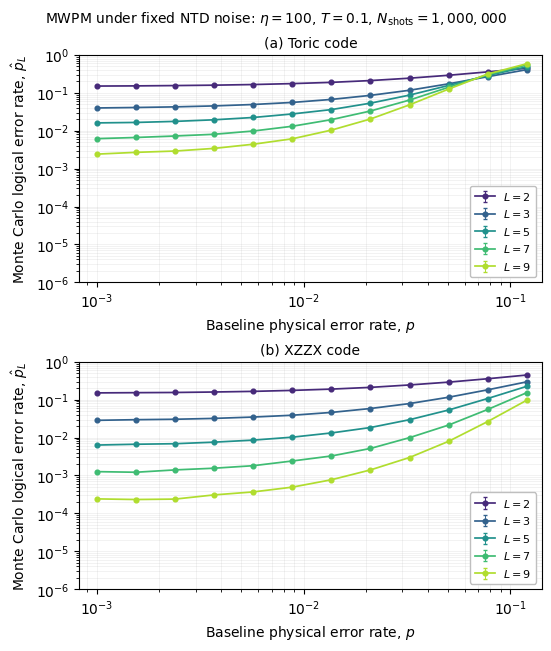

Saved figure1_mc_mwpm.pdf and figure1_mc_mwpm.png


In [16]:
#!/usr/bin/env python3
"""Figure 1: logical error rate versus baseline physical error rate."""

import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pymatching

from __future__ import annotations
import argparse
from dataclasses import dataclass
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

try:
    import pymatching
except ImportError:
    pymatching = None

@dataclass(frozen=True)
class ToricLattice:
    h_star: np.ndarray
    h_plaq: np.ndarray
    xbar: np.ndarray
    zbar: np.ndarray
    horizontal: np.ndarray

def build_toric_lattice(L: int) -> ToricLattice:
    if L < 2: raise ValueError("L must be at least 2")
    n = 2 * L * L
    H = lambda i,j: (i % L) * L + (j % L)
    V = lambda i,j: L * L + (i % L) * L + (j % L)
    h_star, h_plaq = np.zeros((L*L,n),dtype=np.uint8), np.zeros((L*L,n),dtype=np.uint8)

    for i in range(L):
        for j in range(L):
            k = i*L+j
            for e in (H(i,j),H(i-1,j),V(i,j),V(i,j-1)): h_star[k,e] ^= 1
            for e in (H(i,j),H(i,j+1),V(i,j),V(i+1,j)): h_plaq[k,e] ^= 1

    xbar, zbar = np.zeros((2,n),dtype=np.uint8), np.zeros((2,n),dtype=np.uint8)
    for i in range(L): xbar[0,V(i,0)] = 1; zbar[0,H(i,0)] = 1
    for j in range(L): xbar[1,H(0,j)] = 1; zbar[1,V(0,j)] = 1

    horizontal = np.zeros(n,dtype=bool); horizontal[:L*L] = True
    return ToricLattice(h_star,h_plaq,xbar,zbar,horizontal)

def effective_rates(p: float, eta: float, temperature: float, t0: float = 1.2, p_inf: float = 0.5) -> tuple[float,float]:
    p_eff = p + (p_inf-p)*(1-np.exp(-temperature/t0))
    p_a = p_eff/(1+eta); p_b = p_eff*(2*eta+1)/(2*(1+eta))
    if not (0 < p_a < 0.5 and 0 < p_b < 0.5): raise ValueError(f"Invalid effective rates: p_a={p_a:.4g}, p_b={p_b:.4g}")
    return p_a,p_b

def sector_rates(code: str, lattice: ToricLattice, p_a: float, p_b: float) -> tuple[np.ndarray,np.ndarray]:
    n = lattice.horizontal.size
    if code == "toric": return np.full(n,p_a),np.full(n,p_b)
    if code == "xzzx": return np.where(lattice.horizontal,p_a,p_b),np.where(lattice.horizontal,p_b,p_a)
    raise ValueError(f"Unknown code: {code}")

def make_matching(check_matrix: np.ndarray, error_rates: np.ndarray):
    if pymatching is None: raise ImportError("PyMatching is not installed.")
    return pymatching.Matching(check_matrix,weights=np.log((1-error_rates)/error_rates))

def decode_failures(matching, errors: np.ndarray, check_matrix: np.ndarray, logical_test: np.ndarray) -> np.ndarray:
    syndromes = (errors @ check_matrix.T) & 1
    recovery = np.asarray(matching.decode_batch(syndromes),dtype=np.uint8)
    residual = errors ^ recovery
    return np.any((residual @ logical_test.T) & 1,axis=1)

def simulate_point(code: str, lattice: ToricLattice, p: float, eta: float, temperature: float, shots: int, rng: np.random.Generator) -> tuple[float,float]:
    p_a,p_b = effective_rates(p,eta,temperature)
    x_rates,z_rates = sector_rates(code,lattice,p_a,p_b)
    x_matching,z_matching = make_matching(lattice.h_plaq,x_rates),make_matching(lattice.h_star,z_rates)
    x_errors = (rng.random((shots,x_rates.size)) < x_rates).astype(np.uint8)
    z_errors = (rng.random((shots,z_rates.size)) < z_rates).astype(np.uint8)
    x_fail = decode_failures(x_matching,x_errors,lattice.h_plaq,lattice.zbar)
    z_fail = decode_failures(z_matching,z_errors,lattice.h_star,lattice.xbar)
    p_logical = np.count_nonzero(x_fail | z_fail)/shots
    return p_logical,np.sqrt(p_logical*(1-p_logical)/shots)

def run_figure(L_values: list[int], p_values: np.ndarray, eta: float, temperature: float, shots: int, seed: int, output: Path) -> None:
    lattices = {L: build_toric_lattice(L) for L in L_values}
    colors = plt.get_cmap("viridis")(np.linspace(0.12,0.88,len(L_values)))
    rng = np.random.default_rng(seed)

    fig,axes = plt.subplots(2,1,figsize=(5.4,6.4),sharex=True,constrained_layout=True)

    for ax,code,title in zip(axes,("toric","xzzx"),("(a) Toric code","(b) XZZX code")):
        for L,color in zip(L_values,colors):
            estimates,errors = [],[]
            for p in p_values:
                estimate,uncertainty = simulate_point(code,lattices[L],float(p),eta,temperature,shots,rng)
                estimates.append(estimate); errors.append(uncertainty)

            estimates,errors = np.asarray(estimates),np.asarray(errors)

            ax.errorbar(
                p_values,np.maximum(estimates,0.5/shots),yerr=errors,
                marker="o",markersize=3.4,linewidth=1.25,elinewidth=0.7,
                capsize=1.6,color=color,label=fr"$L={L}$"
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(p_values.min()*0.82,p_values.max()*1.18)
        ax.set_ylim(1e-6,1.0)
        ax.set_xticks([1e-3,1e-2,1e-1])
        ax.set_xticklabels([r"$10^{-3}$",r"$10^{-2}$",r"$10^{-1}$"])
        ax.grid(which="both",alpha=0.22,linewidth=0.5)
        ax.set_title(title,fontsize=10)
        ax.set_xlabel(r"Baseline physical error rate, $p$")
        ax.set_ylabel(r"Monte Carlo logical error rate, $\hat{p}_L$")
        ax.legend(
            loc="lower right",frameon=True,facecolor="white",
            framealpha=1.0,edgecolor="0.75",fontsize=8,handlelength=1.8
        )

    axes[0].tick_params(axis="x",which="both",labelbottom=True)

    fig.suptitle(
        fr"MWPM under fixed NTD noise: $\eta={eta:g}$, $T={temperature:g}$, "
        fr"$N_{{\rm shots}}={shots:,}$",fontsize=10
    )

    output.parent.mkdir(parents=True,exist_ok=True)
    fig.savefig(output.with_suffix(".pdf"),bbox_inches="tight")
    fig.savefig(output.with_suffix(".png"),dpi=450,bbox_inches="tight")
    plt.show()
    plt.close(fig)

def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--L",type=int,nargs="+",default=[2,3,5,7,9])
    parser.add_argument("--eta",type=float,default=100.0)
    parser.add_argument("--temperature","--T",type=float,default=0.1)
    parser.add_argument("--shots",type=int,default=1000_000)
    parser.add_argument("--num-points",type=int,default=12)
    parser.add_argument("--p-min",type=float,default=1e-3)
    parser.add_argument("--p-max",type=float,default=1.2e-1)
    parser.add_argument("--seed",type=int,default=20260916)
    parser.add_argument("--output",type=Path,default=Path("figure1_mc_mwpm"))
    args,_ = parser.parse_known_args()

    if args.shots < 1: raise ValueError("--shots must be positive")
    if not (0 < args.p_min < args.p_max < 0.5): raise ValueError("Require 0 < p-min < p-max < 0.5")

    p_values = np.geomspace(args.p_min,args.p_max,args.num_points)
    for p in p_values: effective_rates(float(p),args.eta,args.temperature)

    run_figure(args.L,p_values,args.eta,args.temperature,args.shots,args.seed,args.output)
    print(f"Saved {args.output.with_suffix('.pdf')} and {args.output.with_suffix('.png')}")

if __name__ == "__main__":
    sys.argv = [sys.argv[0]]
    main()

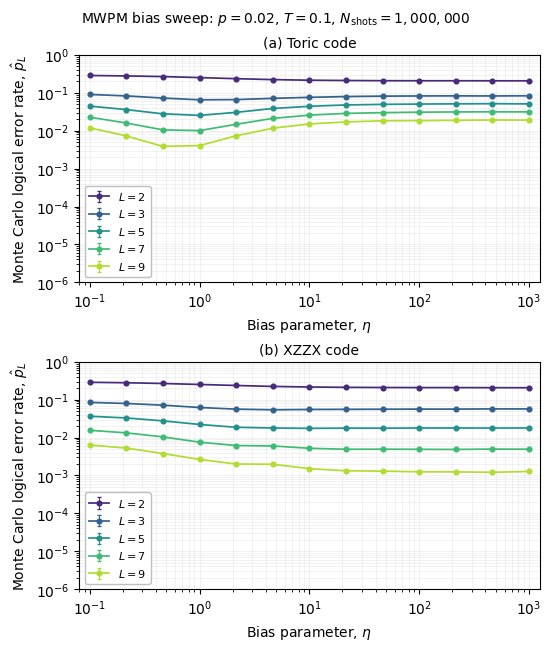

Saved figure2_mc_mwpm.pdf and figure2_mc_mwpm.png


In [26]:
#!/usr/bin/env python3
"""Figure 2: logical error rate versus bias parameter eta with MWPM."""

from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    from figure1_mc_mwpm import build_toric_lattice, effective_rates, simulate_point
except ModuleNotFoundError:
    from __main__ import build_toric_lattice, effective_rates, simulate_point


def run_figure(L_values: list[int], eta_values: np.ndarray, p: float, temperature: float, shots: int, seed: int, output: Path, show: bool) -> None:
    lattices = {L: build_toric_lattice(L) for L in L_values}
    colors = plt.get_cmap("viridis")(np.linspace(0.12, 0.88, len(L_values)))
    rng = np.random.default_rng(seed)

    fig, axes = plt.subplots(2, 1, figsize=(5.4, 6.4), sharex=True, constrained_layout=True)

    for ax, code, title in zip(axes, ("toric", "xzzx"), ("(a) Toric code", "(b) XZZX code")):
        for L, color in zip(L_values, colors):
            estimates, uncertainties = [], []
            for eta in eta_values:
                estimate, uncertainty = simulate_point(code, lattices[L], p, float(eta), temperature, shots, rng)
                estimates.append(estimate); uncertainties.append(uncertainty)

            estimates, uncertainties = np.asarray(estimates), np.asarray(uncertainties)
            ax.errorbar(eta_values, np.maximum(estimates, 0.5 / shots), yerr=uncertainties, marker="o", markersize=3.4, linewidth=1.25, elinewidth=0.7, capsize=1.6, color=color, label=fr"$L={L}$")

        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(eta_values.min() * 0.80, eta_values.max() * 1.25)
        ax.set_ylim(1e-6, 1.0)
        ax.grid(which="both", alpha=0.22, linewidth=0.5)
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(r"Monte Carlo logical error rate, $\hat{p}_L$")
        ax.legend(loc="lower left", frameon=True, facecolor="white", framealpha=1.0, edgecolor="0.75", fontsize=8, handlelength=1.8)

    axes[0].set_xticks([1e-1, 1e0, 1e1, 1e2, 1e3])
    axes[0].set_xticklabels([r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"])
    axes[0].tick_params(axis="x", which="both", labelbottom=True)
    axes[0].set_xlabel(r"Bias parameter, $\eta$")
    axes[1].set_xlabel(r"Bias parameter, $\eta$")

    fig.suptitle(fr"MWPM bias sweep: $p={p:g}$, $T={temperature:g}$, $N_{{\rm shots}}={shots:,}$", fontsize=10)

    output.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(output.with_suffix(".png"), dpi=450, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--L", type=int, nargs="+", default=[2, 3, 5, 7, 9])
    parser.add_argument("--p", type=float, default=0.02)
    parser.add_argument("--temperature", "--T", type=float, default=0.10)
    parser.add_argument("--eta-min", type=float, default=0.1)
    parser.add_argument("--eta-max", type=float, default=1000.0)
    parser.add_argument("--num-points", type=int, default=13)
    parser.add_argument("--shots", type=int, default=1000_000)
    parser.add_argument("--seed", type=int, default=20260917)
    parser.add_argument("--output", type=Path, default=Path("figure2_mc_mwpm"))
    parser.add_argument("--show", action="store_true")
    args, _ = parser.parse_known_args()

    if args.shots < 1: raise ValueError("--shots must be positive")
    if not (0.0 < args.eta_min < args.eta_max): raise ValueError("Require 0 < eta-min < eta-max")

    eta_values = np.geomspace(args.eta_min, args.eta_max, args.num_points)
    for eta in eta_values: effective_rates(args.p, float(eta), args.temperature)

    run_figure(args.L, eta_values, args.p, args.temperature, args.shots, args.seed, args.output, args.show)
    print(f"Saved {args.output.with_suffix('.pdf')} and {args.output.with_suffix('.png')}")


if __name__ == "__main__":
    import sys
    sys.argv = [sys.argv[0], "--show"]
    main()

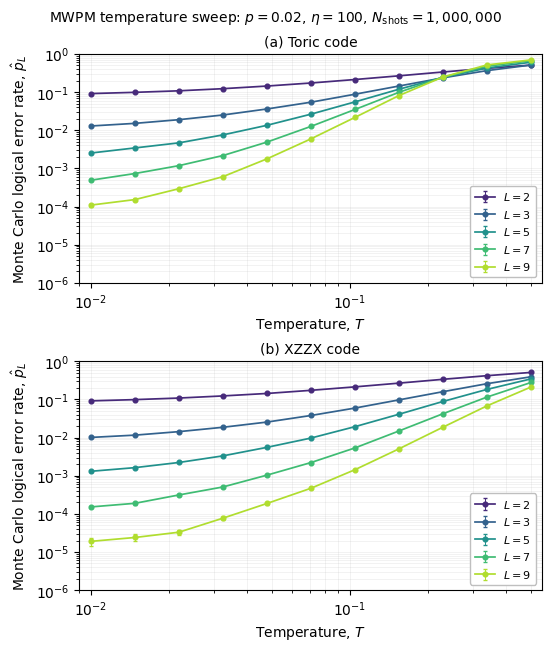

Saved figure3_mc_mwpm.pdf and figure3_mc_mwpm.png


In [25]:
#!/usr/bin/env python3
"""Figure 3: logical error rate versus temperature T with MWPM."""

from __future__ import annotations
import argparse
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

try:
    from figure1_mc_mwpm import build_toric_lattice, effective_rates, simulate_point
except ModuleNotFoundError:
    try:
        from __main__ import build_toric_lattice, effective_rates, simulate_point
    except ImportError as error:
        raise ImportError(
            "Run the Figure 1 definition cell first, or save Figure 1 as "
            "figure1_mc_mwpm.py in the same folder as this script."
        ) from error


def run_figure(L_values: list[int], temperatures: np.ndarray, p: float,
               eta: float, shots: int, seed: int, output: Path) -> None:
    """Run and save the Figure 3 temperature sweep."""
    lattices = {L: build_toric_lattice(L) for L in L_values}
    colors = plt.get_cmap("viridis")(np.linspace(0.12, 0.88, len(L_values)))
    rng = np.random.default_rng(seed)

    fig, axes = plt.subplots(2, 1, figsize=(5.4, 6.4), sharex=True, constrained_layout=True)

    for ax, code, title in zip(axes, ("toric", "xzzx"), ("(a) Toric code", "(b) XZZX code")):
        for L, color in zip(L_values, colors):
            estimates, uncertainties = [], []

            for temperature in temperatures:
                estimate, uncertainty = simulate_point(
                    code, lattices[L], p, eta, float(temperature), shots, rng
                )
                estimates.append(estimate)
                uncertainties.append(uncertainty)

            estimates, uncertainties = np.asarray(estimates), np.asarray(uncertainties)
            ax.errorbar(
                temperatures, np.maximum(estimates, 0.5 / shots), yerr=uncertainties,
                marker="o", markersize=3.4, linewidth=1.25, elinewidth=0.7,
                capsize=1.6, color=color, label=fr"$L={L}$"
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(temperatures.min() * 0.9, temperatures.max() * 1.1)
        ax.set_ylim(1e-6, 1.0)
        ax.grid(which="both", alpha=0.22, linewidth=0.5)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel(r"Temperature, $T$")
        ax.set_ylabel(r"Monte Carlo logical error rate, $\hat{p}_L$")
        ax.legend(
            loc="lower right", frameon=True, facecolor="white",
            framealpha=1.0, edgecolor="0.75", fontsize=8, handlelength=1.8
        )

    axes[0].tick_params(axis="x", which="both", labelbottom=True)

    fig.suptitle(
        fr"MWPM temperature sweep: $p={p:g}$, $\eta={eta:g}$, "
        fr"$N_{{\rm shots}}={shots:,}$", fontsize=10
    )

    output.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(output.with_suffix(".png"), dpi=450, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--L", type=int, nargs="+", default=[2, 3, 5, 7, 9])
    parser.add_argument("--p", type=float, default=0.02)
    parser.add_argument("--eta", type=float, default=100.0)
    parser.add_argument("--T-min", type=float, default=0.01)
    parser.add_argument("--T-max", type=float, default=0.5)
    parser.add_argument("--num-points", type=int, default=11)
    parser.add_argument("--shots", type=int, default=1000_000)
    parser.add_argument("--seed", type=int, default=20260918)
    parser.add_argument("--output", type=Path, default=Path("figure3_mc_mwpm"))
    args, _ = parser.parse_known_args()

    if args.shots < 1:
        raise ValueError("--shots must be positive")
    if not (0.0 < args.T_min < args.T_max):
        raise ValueError("Require 0 < T-min < T-max for a logarithmic temperature axis")

    temperatures = np.geomspace(args.T_min, args.T_max, args.num_points)

    for temperature in temperatures:
        effective_rates(args.p, args.eta, float(temperature))

    run_figure(
        args.L, temperatures, args.p, args.eta,
        args.shots, args.seed, args.output
    )

    print(f"Saved {args.output.with_suffix('.pdf')} and {args.output.with_suffix('.png')}")


if __name__ == "__main__":
    import sys
    sys.argv = [sys.argv[0]]
    main()

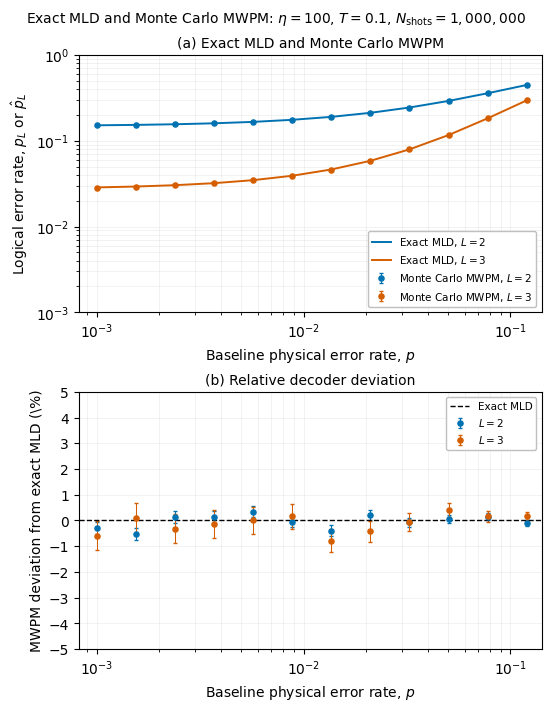

Saved figure4_exact_mld_vs_mwpm.pdf and figure4_exact_mld_vs_mwpm.png


In [ ]:
#!/usr/bin/env python3
"""Figure 4: exact maximum-likelihood decoding versus Monte Carlo MWPM.

The figure validates the XZZX MWPM implementation for L=2 and L=3. Exact
maximum-likelihood (MLD) decoding enumerates all binary error configurations
within each independently decoded sector. MWPM results are sampled using the
same p -> p_eff -> p_NTD^(a,b) noise model and include binomial 1-sigma bars.
"""

from __future__ import annotations

import argparse
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

try:
    from figure1_mc_mwpm import build_toric_lattice, effective_rates, sector_rates, simulate_point
except ModuleNotFoundError:
    try:
        from __main__ import build_toric_lattice, effective_rates, sector_rates, simulate_point
    except ImportError as error:
        raise ImportError("Run the Figure 1 definition cell first, or save Figure 1 as figure1_mc_mwpm.py in the same folder as this script.") from error


@lru_cache(maxsize=None)
def all_binary_errors(n_qubits: int) -> np.ndarray:
    """Return the 2^n binary configurations, feasible here only for L=2,3."""
    indices = np.arange(1 << n_qubits, dtype=np.uint32)
    return ((indices[:, None] >> np.arange(n_qubits)) & 1).astype(np.uint8)


def exact_sector_failure(check_matrix: np.ndarray, logical_test: np.ndarray, rates: np.ndarray) -> float:
    """Exact MLD logical failure for one binary sector."""
    errors = all_binary_errors(rates.size)
    syndrome = (errors @ check_matrix.T) & 1
    syndrome_id = syndrome @ (1 << np.arange(check_matrix.shape[0]))
    logical_class = ((errors @ logical_test.T) & 1) @ np.array([1, 2])
    probabilities = np.prod(np.where(errors, rates, 1.0 - rates), axis=1)
    grouped_id = 4 * syndrome_id + logical_class
    class_probability = np.bincount(grouped_id, weights=probabilities, minlength=(1 << check_matrix.shape[0]) * 4).reshape(-1, 4)
    return 1.0 - np.max(class_probability, axis=1).sum()


def exact_xzzx_failure(L: int, p: float, eta: float, temperature: float) -> float:
    """Combine exact MLD failures of the independent XZZX sectors."""
    lattice = build_toric_lattice(L)
    p_a, p_b = effective_rates(p, eta, temperature)
    x_rates, z_rates = sector_rates("xzzx", lattice, p_a, p_b)
    p_x = exact_sector_failure(lattice.h_plaq, lattice.zbar, x_rates)
    p_z = exact_sector_failure(lattice.h_star, lattice.xbar, z_rates)
    return 1.0 - (1.0 - p_x) * (1.0 - p_z)


def run_figure(p_values: np.ndarray, eta: float, temperature: float, shots: int, seed: int, output: Path) -> None:
    """Plot decoder comparison and MWPM deviation from exact MLD."""
    rng = np.random.default_rng(seed)
    fig, (ax, ax_ratio) = plt.subplots(2, 1, figsize=(5.4, 7.0), constrained_layout=True)
    styles = {2: ("#0072B2", "o"), 3: ("#D55E00", "o")}
    deviation_extrema: list[float] = []

    for L in (2, 3):
        color, marker = styles[L]
        lattice = build_toric_lattice(L)
        exact_values, mwpm_values, uncertainties = [], [], []

        for p in p_values:
            exact_values.append(exact_xzzx_failure(L, float(p), eta, temperature))
            estimate, uncertainty = simulate_point("xzzx", lattice, float(p), eta, temperature, shots, rng)
            mwpm_values.append(estimate)
            uncertainties.append(uncertainty)

        exact_values, mwpm_values, uncertainties = map(np.asarray, (exact_values, mwpm_values, uncertainties))

        ax.plot(p_values, np.maximum(exact_values, 0.5 / shots), color=color, linewidth=1.4, label=fr"Exact MLD, $L={L}$")
        ax.errorbar(p_values, np.maximum(mwpm_values, 0.5 / shots), yerr=uncertainties, linestyle="none", marker=marker, markersize=3.7, color=color, elinewidth=0.75, capsize=1.7, label=fr"Monte Carlo MWPM, $L={L}$")

        reliable = exact_values * shots >= 10.0
        deviation_percent = 100.0 * (mwpm_values[reliable] / exact_values[reliable] - 1.0)
        deviation_error_percent = 100.0 * uncertainties[reliable] / exact_values[reliable]

        ax_ratio.errorbar(p_values[reliable], deviation_percent, yerr=deviation_error_percent, linestyle="none", marker=marker, markersize=3.7, color=color, elinewidth=0.75, capsize=1.7, label=fr"$L={L}$")

        if deviation_percent.size:
            deviation_extrema.extend((deviation_percent - deviation_error_percent).tolist())
            deviation_extrema.extend((deviation_percent + deviation_error_percent).tolist())

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(p_values.min() * 0.82, p_values.max() * 1.18)
    ax.set_ylim(1e-3, 1.0)
    ax.grid(which="both", alpha=0.22, linewidth=0.5)
    ax.set_xlabel(r"Baseline physical error rate, $p$")
    ax.set_ylabel(r"Logical error rate, $p_L$ or $\hat{p}_L$")
    ax.legend(loc="lower right", frameon=True, facecolor="white", framealpha=1.0, edgecolor="0.75", fontsize=7.5, handlelength=1.8)
    ax.set_title(r"(a) Exact MLD and Monte Carlo MWPM", fontsize=10)

    ax_ratio.axhline(0.0, color="black", linestyle="--", linewidth=1.0, label="Exact MLD")
    ax_ratio.set_xscale("log")
    ax_ratio.set_xlim(p_values.min() * 0.82, p_values.max() * 1.18)
    ax_ratio.grid(which="both", alpha=0.22, linewidth=0.5)
    ax_ratio.set_xlabel(r"Baseline physical error rate, $p$")
    ax_ratio.set_ylabel(r"MWPM deviation from exact MLD (\%)")
    ax_ratio.set_title(r"(b) Relative decoder deviation", fontsize=10)

    if deviation_extrema:
        limit = max(5.0, float(np.ceil(max(abs(value) for value in deviation_extrema))))
        ax_ratio.set_ylim(-limit, limit)
        ax_ratio.yaxis.set_major_locator(MultipleLocator(1.0 if limit <= 6.0 else 2.0))

    ax_ratio.legend(loc="best", frameon=True, facecolor="white", framealpha=1.0, edgecolor="0.75", fontsize=7.5, handlelength=1.8)

    fig.suptitle(fr"Exact MLD and Monte Carlo MWPM: $\eta={eta:g}$, $T={temperature:g}$, $N_{{\rm shots}}={shots:,}$", fontsize=10)

    output.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(output.with_suffix(".png"), dpi=450, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def main() -> None:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--eta", type=float, default=100.0)
    parser.add_argument("--temperature", "--T", type=float, default=0.10)
    parser.add_argument("--shots", type=int, default=1_000_000, help="Monte Carlo shots per (L, p) point.")
    parser.add_argument("--num-points", type=int, default=12)
    parser.add_argument("--p-min", type=float, default=1e-3)
    parser.add_argument("--p-max", type=float, default=1.2e-1)
    parser.add_argument("--seed", type=int, default=20260919)
    parser.add_argument("--output", type=Path, default=Path("figure4_exact_mld_vs_mwpm"))
    args, _unknown_jupyter_args = parser.parse_known_args()

    if args.shots < 1:
        raise ValueError("--shots must be positive")
    if not (0.0 < args.p_min < args.p_max < 0.5):
        raise ValueError("Require 0 < p-min < p-max < 0.5")

    p_values = np.geomspace(args.p_min, args.p_max, args.num_points)
    for p in p_values:
        effective_rates(float(p), args.eta, args.temperature)

    run_figure(p_values, args.eta, args.temperature, args.shots, args.seed, args.output)
    print(f"Saved {args.output.with_suffix('.pdf')} and {args.output.with_suffix('.png')}")


if __name__ == "__main__":
    main()